{'topic': '猫咪', 'poem': '**《咏猫》**\n\n狸奴昼卧暖阳斜，\n耳动风惊落叶哗。\n忽见梁间飞燕影，\n腾身一跃戏窗纱。', 'ci_poem': '这里为你填一首词，选用的是格律轻快、适合描写生活闲趣的词牌**《浣溪沙》**。\n\n### **《浣溪沙·狸奴午梦》**\n\n午后窗纱透暖光，\n狸奴蜷卧旧藤床，\n金瞳半闭意慵懒。\n\n忽见飞虫掠影忙，\n纵身一跃扑空囊，\n甩尾回眸笑主狂。\n\n---\n\n**【赏析】**\n*   **上片**写静：描绘了猫咪在午后阳光下，蜷缩在藤椅上打盹的惬意模样，“金瞳半闭”勾勒出它那种特有的高贵与慵懒。\n*   **下片**写动：笔锋一转，捕捉到猫咪被飞虫吸引，瞬间从静止变为扑击的动态画面。最后“扑空”后的甩尾和眼神，生动地表现了猫咪既傲娇又可爱的性格，仿佛它在嘲笑主人的大惊小怪，充满了生活情趣。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '有一天，主人问家里的橘猫：“你为什么总是把桌上的东西推下去？”\n\n橘猫淡定地舔了舔爪子，说：“我在测试重力是否还正常工作。毕竟，如果我不亲自确认一下，万一哪天重力失效了，我跳起来却掉不下去，那多尴尬？”\n\n主人：“……那你昨天把我的手机也推下去了，这也是为了科学？”\n\n橘猫瞥了他一眼：“不，那个纯粹是因为它响得太烦人，而且我想看看屏幕碎掉的声音是不是比你的呼噜声好听。” 🐱📱', 'ci_poem': '这是一首以**《清平乐》**为词牌填写的关于猫咪的词。这首词试图捕捉猫咪慵懒、傲娇又亲昵的神态，以及它与主人之间微妙而温馨的互动。\n\n### **《清平乐·狸奴昼寝》**\n\n**绒团初醒，**\n**斜倚窗棂静。**\n**金缕阳光穿户影，**\n**闲数飞尘不定。**\n\n**轻呼软语相迎，**\n**蹭衣却步还停。**\n**最是夜深人静处，**\n**呼噜伴梦轻盈。**\n\n---\n\n### **【注释与赏析】**\n\n*   **狸奴**：古人对猫的爱称。\n*   **上片（写景与态）**：\n    *   描绘了猫咪午睡初醒时的样子，像一团柔软的绒毛，安静地靠在窗边。\n    *   “金缕阳光”与“飞尘”营造出午后静谧、时光缓慢流淌的氛围，猫咪眼

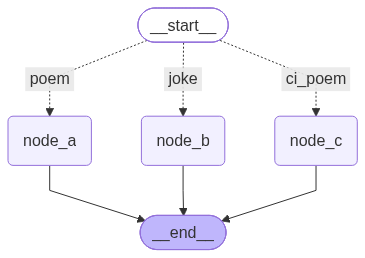

In [ ]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal,Sequence

load_dotenv()

# 初始化模型
model = init_chat_model(
    "qwen3.7-plus-2026-05-26",
    model_provider="openai",
    temperature=0.5,
    max_tokens=1024,
    timeout=60,
    max_retries=3,
    base_url=os.getenv("DASHSCOPE_API_URL"),
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    extra_body={
        "thinking": {
            "type": "disabled"
            }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str
    content_type: str

def node_a(state: OverAllState) -> OverAllState:
    '''
    生成七言绝句
    '''
    poem = model.invoke([HumanMessage(content=f"写一首关于{state['topic']}主题的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    '''
    生成笑话
    '''
    joke = model.invoke([HumanMessage(content=f"写一个关于{state['topic']}主题的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    '''
    生成词
    '''
    ci_poem = model.invoke([HumanMessage(content=f"写一首关于{state['topic']}主题的词")]).content

    return {
        "ci_poem": ci_poem
    }

def my_route(state: OverAllState) -> Sequence[Literal["poem","joke","ci_poem"]]:
    '''
    路由
    '''
    if "诗" in state["content_type"]:
        return ["poem","ci_poem"]
    else:
        return ["joke","ci_poem"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_conditional_edges(
    START,
    my_route,
    path_map={
        "poem": "node_a",
        "joke": "node_b",
        "ci_poem": "node_c"
    }
    )

# builder.add_edge("node_a", END)
# builder.add_edge("node_b", END)
# builder.add_edge("node_c", END)

graph = builder.compile()
result = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(result)

result = graph.invoke({"topic": "猫咪", "content_type": "笑话"})
print(result)

from IPython.display import display
display(graph)